In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap

In [29]:
DRIVE_ROOT = Path("/content/drive/MyDrive")
DATA_DIR_CLOUD = DRIVE_ROOT / "semantic-drift/news_dataset/processed/results"
DATA_DIR_REDDIT = DRIVE_ROOT / "semantic-drift/reddit_data/processed/results"
RESULTS_DIR = DRIVE_ROOT / "semantic-drift/results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
news_df = pd.read_csv(DATA_DIR_CLOUD / "cloud_news_contexts.csv")
reddit_df = pd.read_csv(DATA_DIR_REDDIT / "cloud_contexts_new.csv")

old_contexts = news_df["text"].dropna().tolist()
new_contexts = reddit_df["text"].dropna().tolist()

print("Old contexts:", len(old_contexts))
print("New contexts:", len(new_contexts))

Old contexts: 206
New contexts: 325


In [14]:
print("OLD SAMPLES:")
for c in old_contexts[:5]:
    print("-", c)

print("\nNEW SAMPLES:")
for c in new_contexts[:5]:
    print("-", c)

OLD SAMPLES:
- In 1997, scientists announced they had found one of the most massive stars known, behind a dense dust cloud in the Milky Way that had previously concealed it.
- HEADLINE - don't get out of bed today, because if the real world doesn't end to today, then the banks will collapse, or the sky will fall in, or we'll find something else to threaten you with - god I wish the 80's were still here, if the IRA didn't get you, and you didn't see a mushroom cloud - everything was just fine.
- "Every time the dump spews a large cloud of smoke, I start coughing," says Priscilla, whose Saint John school in Korogocho slum is often shrouded in a cloud of thick noxious fumes.
- Abood said he was still waiting when the Blackwater guards climbed inside their vehicles, set off smoke grenades in the circle and sped away in a green-and-orange cloud toward the Green Zone.
- Police closed off three roads and evacuated homes in central London as a cloud of noxious smoke filled the air.

NEW SAMPLE

In [15]:
old_emb = embed_model.encode(old_contexts, batch_size=64, show_progress_bar=True)
new_emb = embed_model.encode(new_contexts, batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [16]:
np.save(DATA_DIR_CLOUD / "cloud_old_embeddings.npy", old_emb)
np.save(DATA_DIR_CLOUD / "cloud_new_embeddings.npy", new_emb)

print("Saved embeddings.")

Saved embeddings.


In [17]:
old_mean = np.mean(old_emb, axis=0)
new_mean = np.mean(new_emb, axis=0)

drift_score = 1 - cosine_similarity(
    old_mean.reshape(1, -1),
    new_mean.reshape(1, -1)
)[0][0]

print("Drift score:", drift_score)

Drift score: 0.7365945


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


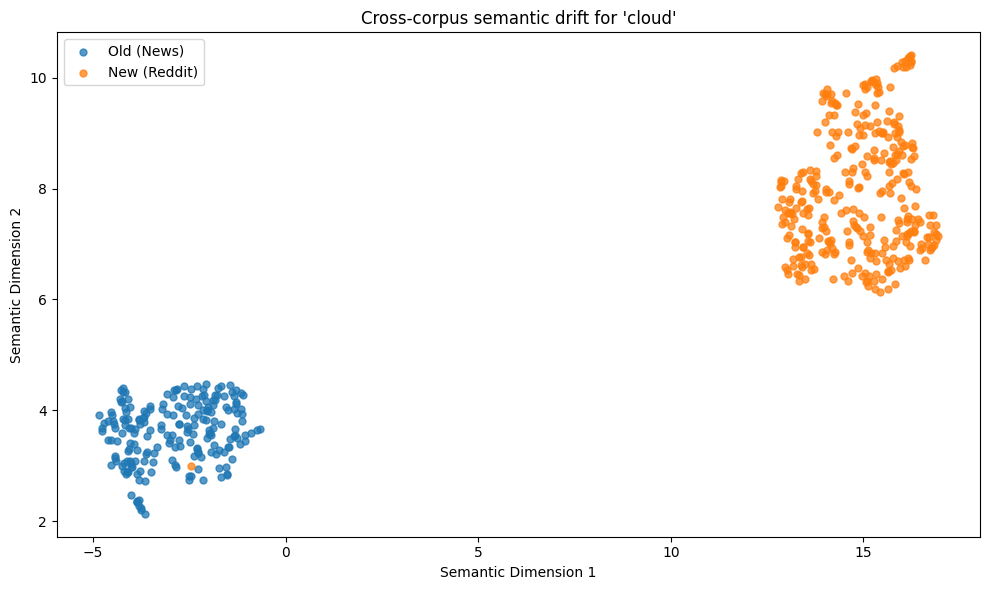

In [18]:
all_emb = np.vstack([old_emb, new_emb])
labels = np.array(["Old (News)"] * len(old_emb) + ["New (Reddit)"] * len(new_emb))

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(all_emb)

old_mask = labels == "Old (News)"
new_mask = labels == "New (Reddit)"

plt.figure(figsize=(10, 6))
plt.scatter(coords[old_mask, 0], coords[old_mask, 1], s=25, alpha=0.75, label="Old (News)")
plt.scatter(coords[new_mask, 0], coords[new_mask, 1], s=25, alpha=0.75, label="New (Reddit)")
plt.title("Cross-corpus semantic drift for 'cloud'")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

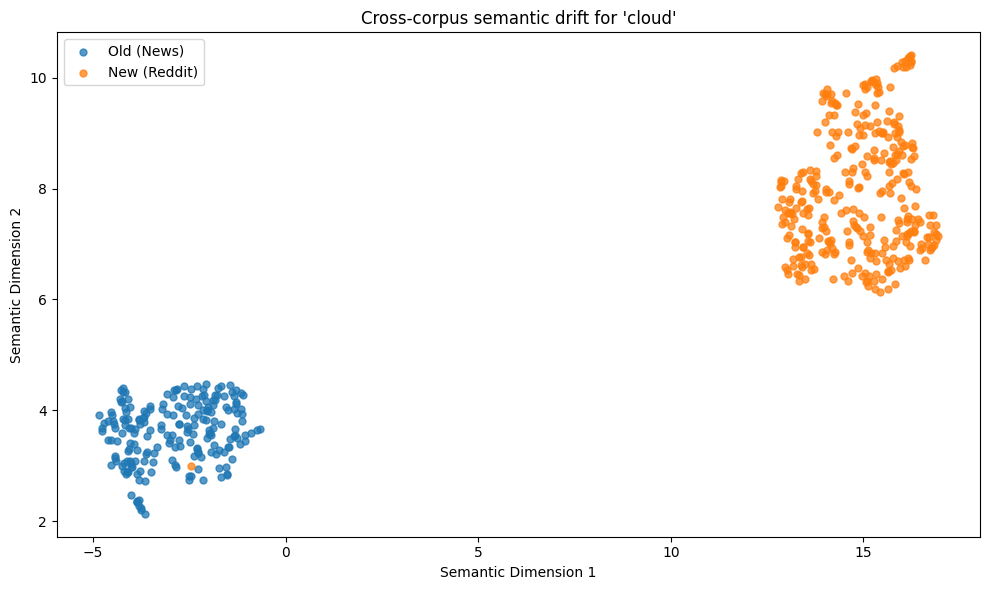

Saved plot.


In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(coords[old_mask, 0], coords[old_mask, 1], s=25, alpha=0.75, label="Old (News)")
plt.scatter(coords[new_mask, 0], coords[new_mask, 1], s=25, alpha=0.75, label="New (Reddit)")
plt.title("Cross-corpus semantic drift for 'cloud'")
plt.xlabel("Semantic Dimension 1")
plt.ylabel("Semantic Dimension 2")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cloud_news_vs_reddit_umap.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plot.")

In [20]:
def interpret_drift_score(score):
    if score < 0.05:
        return "very little semantic change"
    elif score < 0.15:
        return "small semantic shift"
    elif score < 0.30:
        return "moderate semantic shift"
    else:
        return "strong semantic shift"

explanation = f"""
Word analyzed: cloud

Old corpus: formal news contexts
New corpus: Reddit contexts

Number of old contexts: {len(old_contexts)}
Number of new contexts: {len(new_contexts)}

The drift score is {drift_score:.3f}, which suggests {interpret_drift_score(drift_score)}.

This indicates that the historical/formal meaning of "cloud" differs noticeably from its modern Reddit usage.
In the older corpus, the word is primarily associated with physical or atmospheric phenomena such as smoke clouds, cloud cover, and visible clouds in the sky.
In the modern Reddit corpus, the word is mainly associated with cloud computing, cloud storage, servers, and infrastructure.
"""

print(explanation)


Word analyzed: cloud

Old corpus: formal news contexts
New corpus: Reddit contexts

Number of old contexts: 206
Number of new contexts: 325

The drift score is 0.737, which suggests strong semantic shift.

This indicates that the historical/formal meaning of "cloud" differs noticeably from its modern Reddit usage.
In the older corpus, the word is primarily associated with physical or atmospheric phenomena such as smoke clouds, cloud cover, and visible clouds in the sky.
In the modern Reddit corpus, the word is mainly associated with cloud computing, cloud storage, servers, and infrastructure.



In [21]:
with open(RESULTS_DIR / "cloud_news_vs_reddit_explanation.txt", "w", encoding="utf-8") as f:
    f.write(explanation)

print("Saved explanation.")

Saved explanation.


K-Means

In [22]:
import numpy as np

all_emb = np.vstack([old_emb, new_emb])

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

labels = kmeans.fit_predict(all_emb)

print("Cluster counts:")
print(np.bincount(labels))

Cluster counts:
[207 324]


In [24]:
contexts = old_contexts + new_contexts

cluster_df = pd.DataFrame({
    "text": contexts,
    "cluster": labels
})

In [25]:
for c in sorted(cluster_df["cluster"].unique()):
    print("Cluster:", c)

    examples = cluster_df[cluster_df["cluster"] == c]["text"].head(10)

    for e in examples:
        print("-", e)

Cluster: 0
- In 1997, scientists announced they had found one of the most massive stars known, behind a dense dust cloud in the Milky Way that had previously concealed it.
- HEADLINE - don't get out of bed today, because if the real world doesn't end to today, then the banks will collapse, or the sky will fall in, or we'll find something else to threaten you with - god I wish the 80's were still here, if the IRA didn't get you, and you didn't see a mushroom cloud - everything was just fine.
- "Every time the dump spews a large cloud of smoke, I start coughing," says Priscilla, whose Saint John school in Korogocho slum is often shrouded in a cloud of thick noxious fumes.
- Abood said he was still waiting when the Blackwater guards climbed inside their vehicles, set off smoke grenades in the circle and sped away in a green-and-orange cloud toward the Green Zone.
- Police closed off three roads and evacuated homes in central London as a cloud of noxious smoke filled the air.
- A few days 

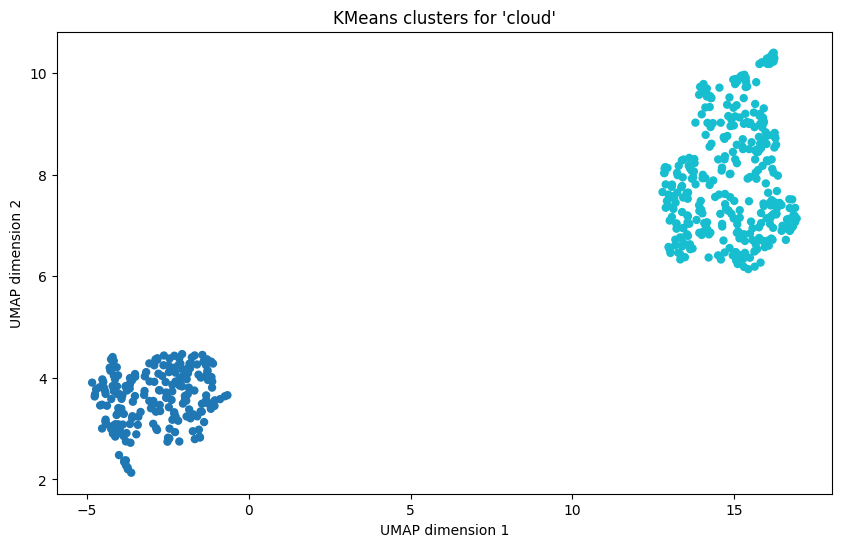

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="tab10", s=25)

plt.title("KMeans clusters for 'cloud'")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")

plt.show()